# Cross-Technology QC Metrics Comparison

Compare gene and guide mapping metrics across datasets.

**Input:** `latest_qc_paths.tsv`  
**Output:** Combined metrics TSVs and comparison barplots

In [78]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [79]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

# Add config to path for color loader
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [80]:
# Paths
RUN_LABEL = "cleanser_unified"  # Change to "cleanser_unified" etc. to switch runs
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
QC_PATHS_FILE = BASE_DIR / "manifests" / f"{RUN_LABEL}_qc_paths_local.tsv"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading paths from: {QC_PATHS_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Reading paths from: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/manifests/cleanser_unified_qc_paths_local.tsv
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified


In [81]:
# Load the paths manifest
paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")
paths_df

,dataset,qc_dir,gene_metrics,guide_metrics,intended_target_results,intended_target_metrics,trans_results,trans_metrics
0,Hon_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,mapping_gene/Hon_WTC11-benchmark_TF-Perturb-se...,mapping_guide/Hon_WTC11-benchmark_TF-Perturb-s...,intended_target/Hon_WTC11-benchmark_TF-Perturb...,intended_target/Hon_WTC11-benchmark_TF-Perturb...,trans/Hon_WTC11-benchmark_TF-Perturb-seq_trans...,trans/Hon_WTC11-benchmark_TF-Perturb-seq_trans...
1,Huangfu_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,mapping_gene/Huangfu_WTC11-benchmark_TF-Pertur...,mapping_guide/Huangfu_WTC11-benchmark_TF-Pertu...,intended_target/Huangfu_WTC11-benchmark_TF-Per...,intended_target/Huangfu_WTC11-benchmark_TF-Per...,trans/Huangfu_WTC11-benchmark_TF-Perturb-seq_t...,trans/Huangfu_WTC11-benchmark_TF-Perturb-seq_t...
2,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,/cellar/users/aklie/data/datasets/tf_perturb_s...,mapping_gene/Gersbach_WTC11-benchmark_TF-Pertu...,mapping_guide/Gersbach_WTC11-benchmark_TF-Pert...,intended_target/Gersbach_WTC11-benchmark_TF-Pe...,intended_target/Gersbach_WTC11-benchmark_TF-Pe...,trans/Gersbach_WTC11-benchmark_TF-Perturb-seq_...,trans/Gersbach_WTC11-benchmark_TF-Perturb-seq_...
3,Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2,/cellar/users/aklie/data/datasets/tf_perturb_s...,mapping_gene/Gersbach_WTC11-benchmark_TF-Pertu...,mapping_guide/Gersbach_WTC11-benchmark_TF-Pert...,intended_target/Gersbach_WTC11-benchmark_TF-Pe...,intended_target/Gersbach_WTC11-benchmark_TF-Pe...,trans/Gersbach_WTC11-benchmark_TF-Perturb-seq_...,trans/Gersbach_WTC11-benchmark_TF-Perturb-seq_...
4,Engreitz_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,mapping_gene/Engreitz_WTC11-benchmark_TF-Pertu...,mapping_guide/Engreitz_WTC11-benchmark_TF-Pert...,intended_target/Engreitz_WTC11-benchmark_TF-Pe...,intended_target/Engreitz_WTC11-benchmark_TF-Pe...,trans/Engreitz_WTC11-benchmark_TF-Perturb-seq_...,trans/Engreitz_WTC11-benchmark_TF-Perturb-seq_...


## Gene Metrics

In [82]:
# Load and combine gene metrics
gene_metrics_list = []
for _, row in paths_df.iterrows():
    gene_path = Path(row['qc_dir']) / row['gene_metrics']
    if gene_path.exists():
        df = pd.read_csv(gene_path, sep="\t")
        df['dataset'] = row['dataset']
        gene_metrics_list.append(df)
    else:
        print(f"Warning: {gene_path} not found")

gene_metrics_df = pd.concat(gene_metrics_list, ignore_index=True)
gene_metrics_df.head()

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,genes_median,...,genes_q25,genes_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset
0,all,73458,4889.0,4927.8650,2290.8943,168.0,19969.0,3631.0,6254.0,2459.0,...,1974.0,2948.0,5.385402,5.785201,2.695221,0.0,14.995811,4.046174,7.015723,Hon_WTC11-benchmark_TF-Perturb-seq
1,IGVFDS6244NAXC,25061,5275.0,5176.0195,2674.9124,168.0,19969.0,3760.0,6794.0,2606.0,...,2033.0,3126.0,5.445213,5.713920,2.740804,0.0,14.995811,3.960591,7.082357,Hon_WTC11-benchmark_TF-Perturb-seq
2,IGVFDS8721BKRO,22961,4832.0,4865.2270,2135.2905,168.0,18683.0,3615.0,6105.0,2432.0,...,1965.0,2889.0,5.569759,6.022205,2.776995,0.0,14.994623,4.224584,7.242857,Hon_WTC11-benchmark_TF-Perturb-seq
3,IGVFDS9613DDRB,25436,4636.0,4739.9146,1972.7982,168.0,19346.0,3567.0,5858.0,2365.0,...,1943.0,2816.0,5.184914,5.641486,2.557408,0.0,14.981413,3.969375,6.710468,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,3856.0,3791.9300,2444.5752,277.0,24957.0,2112.0,5240.0,2189.0,...,1347.0,2751.0,7.802875,8.011471,4.370673,0.0,19.993950,5.048543,10.363618,Huangfu_WTC11-benchmark_TF-Perturb-seq


In [83]:
# Save combined gene metrics
gene_metrics_df.to_csv(OUTPUT_DIR / "combined_gene_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_gene_metrics.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/combined_gene_metrics.tsv


In [84]:
# Filter to 'all' batch (aggregate metrics)
gene_all = gene_metrics_df[gene_metrics_df['batch'] == 'all'].copy()
gene_all['dataset'] = pd.Categorical(gene_all['dataset'], categories=dataset_order, ordered=True)
gene_all = gene_all.sort_values('dataset')
gene_all

,batch,n_cells,umi_median,umi_mean,umi_std,umi_min,umi_max,umi_q25,umi_q75,genes_median,...,genes_q25,genes_q75,mito_median,mito_mean,mito_std,mito_min,mito_max,mito_q25,mito_q75,dataset
0,all,73458,4889.0,4927.8650,2290.8943,168.0,19969.0,3631.0,6254.00,2459.0,...,1974.0,2948.0,5.385402,5.785201,2.695221,0.0,14.995811,4.046174,7.015723,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,3856.0,3791.9300,2444.5752,277.0,24957.0,2112.0,5240.00,2189.0,...,1347.0,2751.0,7.802875,8.011471,4.370673,0.0,19.993950,5.048543,10.363618,Huangfu_WTC11-benchmark_TF-Perturb-seq
9,all,67436,27183.5,26108.2730,19483.9180,1018.0,167928.0,5578.0,39050.25,6713.0,...,2602.0,7813.0,8.490501,9.017157,4.448621,0.0,19.998466,6.278608,11.436847,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3
14,all,43376,15639.5,19935.6230,19685.3650,1002.0,178963.0,1390.0,33559.00,5016.0,...,1042.0,7116.0,5.753859,6.650649,5.484490,0.0,19.998398,1.719567,9.672135,Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2
19,all,467119,1098.0,1343.5072,1294.5315,46.0,29219.0,110.0,1970.00,818.0,...,99.0,1334.0,9.537299,10.079828,4.545453,0.0,19.997446,6.453716,13.483146,Engreitz_WTC11-benchmark_TF-Perturb-seq


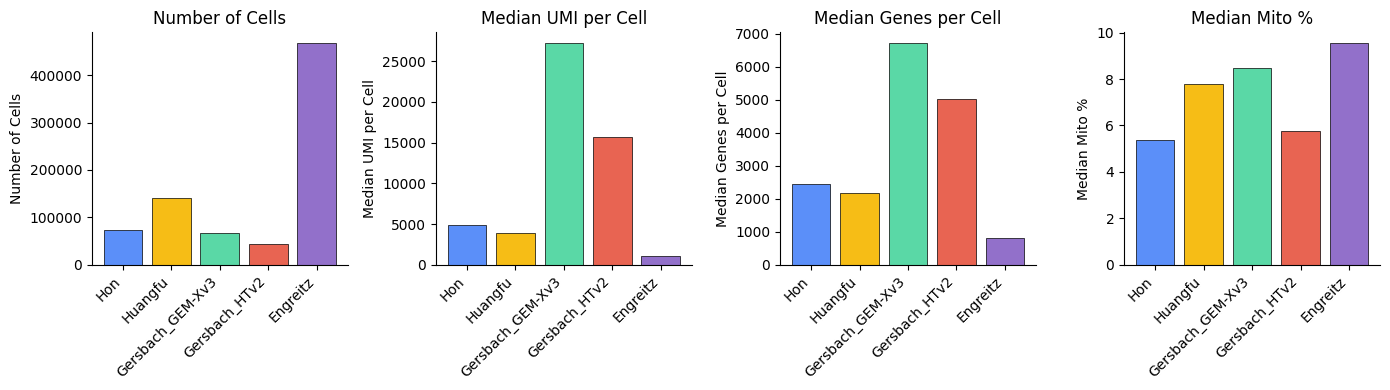

In [85]:
# Key gene metrics to compare (skip any not present in data)
gene_metrics_to_plot = [
    ('n_cells', 'Number of Cells'),
    ('umi_median', 'Median UMI per Cell'),
    ('genes_median', 'Median Genes per Cell'),
    ('mito_median', 'Median Mito %'),
]
gene_metrics_to_plot = [(col, title) for col, title in gene_metrics_to_plot if col in gene_all.columns]

fig, axes = plt.subplots(1, len(gene_metrics_to_plot), figsize=(3.5 * len(gene_metrics_to_plot), 4))
if len(gene_metrics_to_plot) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, gene_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in gene_all['dataset']]
    bars = ax.bar(range(len(gene_all)), gene_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(gene_all)))
    ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in gene_all['dataset']], 
                       rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gene_metrics_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Guide Metrics

In [86]:
# Load and combine guide metrics
guide_metrics_list = []
for _, row in paths_df.iterrows():
    guide_path = Path(row['qc_dir']) / row['guide_metrics']
    if guide_path.exists():
        df = pd.read_csv(guide_path, sep="\t")
        df['dataset'] = row['dataset']
        guide_metrics_list.append(df)
    else:
        print(f"Warning: {guide_path} not found")

guide_metrics_df = pd.concat(guide_metrics_list, ignore_index=True)
guide_metrics_df.head()

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,73458,829.0,1025.563056,871.969370,1.0,8285.0,346.0,1448.0,1.572586,...,67148,38572,0.914101,416.0,244.5,277.689904,313.407272,0.0,2855.0,Hon_WTC11-benchmark_TF-Perturb-seq
1,IGVFDS6244NAXC,25061,800.0,995.402458,880.144392,1.0,8285.0,271.0,1431.0,1.395036,...,21682,12923,0.865169,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
2,IGVFDS8721BKRO,22961,818.0,1014.057227,859.516054,2.0,7515.0,356.0,1426.0,1.734593,...,21516,12283,0.937067,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
3,IGVFDS9613DDRB,25436,864.0,1065.665278,873.566521,6.0,7780.0,396.0,1483.0,1.601274,...,23950,13366,0.941579,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,0.942032,...,92010,63146,0.651394,416.0,280.5,319.862981,372.735370,2.0,3408.0,Huangfu_WTC11-benchmark_TF-Perturb-seq


In [87]:
# Save combined guide metrics
guide_metrics_df.to_csv(OUTPUT_DIR / "combined_guide_metrics.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'combined_guide_metrics.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/combined_guide_metrics.tsv


In [88]:
# Filter to 'all' batch (aggregate metrics)
guide_all = guide_metrics_df[guide_metrics_df['batch'] == 'all'].copy()
guide_all['dataset'] = pd.Categorical(guide_all['dataset'], categories=dataset_order, ordered=True)
guide_all = guide_all.sort_values('dataset')
guide_all

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,73458,829.0,1025.563056,871.969370,1.0,8285.0,346.0,1448.0,1.572586,...,67148,38572,0.914101,416.0,244.5,277.689904,313.407272,0.0,2855.0,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,0.942032,...,92010,63146,0.651394,416.0,280.5,319.862981,372.735370,2.0,3408.0,Huangfu_WTC11-benchmark_TF-Perturb-seq
9,all,67436,451.0,979.882318,1279.172310,1.0,17324.0,52.0,1478.0,1.083931,...,46928,29225,0.695889,416.0,154.0,175.711538,200.409974,0.0,2030.0,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3
14,all,43376,72.0,884.965027,1904.103784,1.0,22687.0,45.0,401.0,0.620043,...,15077,8241,0.347589,416.0,56.0,64.651442,74.210486,0.0,668.0,Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2
19,all,467119,4.0,18.346278,42.292329,1.0,1020.0,2.0,10.0,0.234405,...,85499,66126,0.183035,416.0,233.5,263.209135,319.318841,0.0,3295.0,Engreitz_WTC11-benchmark_TF-Perturb-seq


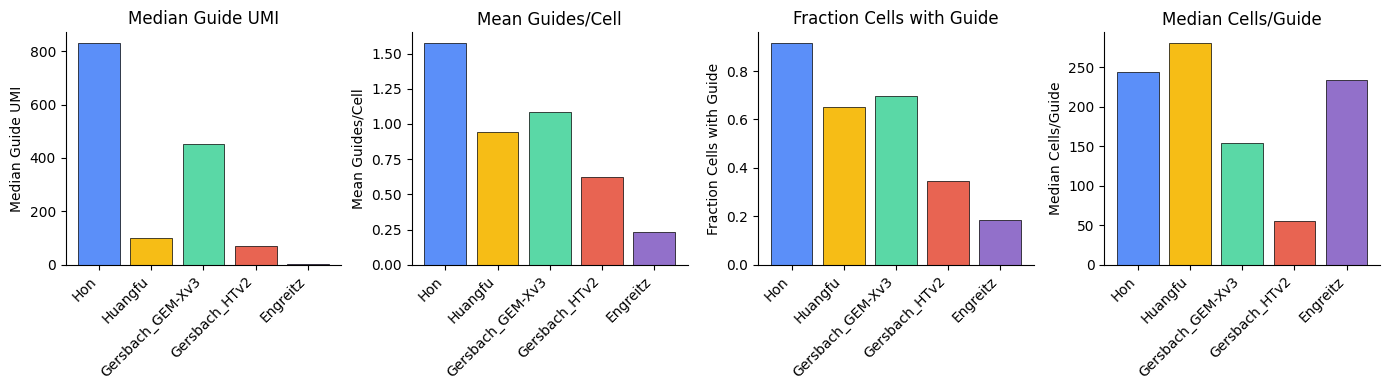

In [89]:
# Key guide metrics to compare
guide_metrics_to_plot = [
    ('guide_umi_median', 'Median Guide UMI'),
    ('guides_per_cell_mean', 'Mean Guides/Cell'),
    ('frac_cells_with_guide', 'Fraction Cells with Guide'),
    ('cells_per_guide_median', 'Median Cells/Guide'),
]

fig, axes = plt.subplots(1, len(guide_metrics_to_plot), figsize=(3.5 * len(guide_metrics_to_plot), 4))

for ax, (col, title) in zip(axes, guide_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
    bars = ax.bar(range(len(guide_all)), guide_all[col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(guide_all)))
    ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                       rotation=45, ha='right')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_metrics_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Combined Summary Plot

In [90]:
# Create a combined summary with key metrics (only include gene cols present in data)
gene_summary_cols = ['dataset', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_all.columns:
    gene_summary_cols.insert(3, 'genes_median')

summary = gene_all[gene_summary_cols].merge(
    guide_all[['dataset', 'guide_umi_median', 'guides_per_cell_median', 'frac_cells_with_guide', 'cells_per_guide_median']],
    on='dataset'
)
summary

,dataset,n_cells,umi_median,genes_median,mito_median,guide_umi_median,guides_per_cell_median,frac_cells_with_guide,cells_per_guide_median
0,Hon_WTC11-benchmark_TF-Perturb-seq,73458,4889.0,2459.0,5.385402,829.0,1.0,0.914101,244.5
1,Huangfu_WTC11-benchmark_TF-Perturb-seq,141251,3856.0,2189.0,7.802875,99.0,1.0,0.651394,280.5
2,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,67436,27183.5,6713.0,8.490501,451.0,1.0,0.695889,154.0
3,Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2,43376,15639.5,5016.0,5.753859,72.0,0.0,0.347589,56.0
4,Engreitz_WTC11-benchmark_TF-Perturb-seq,467119,1098.0,818.0,9.537299,4.0,0.0,0.183035,233.5


In [91]:
# Save summary
summary.to_csv(OUTPUT_DIR / "metrics_summary.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_summary.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/metrics_summary.tsv


## Metrics by Lane

Compare metrics across individual lanes (batches) within each dataset.

In [92]:
# Get per-lane data (exclude 'all' aggregate)
gene_by_lane = gene_metrics_df[gene_metrics_df['batch'] != 'all'].copy()
guide_by_lane = guide_metrics_df[guide_metrics_df['batch'] != 'all'].copy()

# Add short dataset names for plotting
gene_by_lane['lab'] = gene_by_lane['dataset'].str.replace('_WTC11-benchmark_TF-Perturb-seq', '', regex=False)
guide_by_lane['lab'] = guide_by_lane['dataset'].str.replace('_WTC11-benchmark_TF-Perturb-seq', '', regex=False)

# Build gene column list dynamically
gene_lane_cols = ['batch', 'dataset', 'lab', 'n_cells', 'umi_median', 'mito_median']
if 'genes_median' in gene_by_lane.columns:
    gene_lane_cols.insert(5, 'genes_median')

# Merge gene and guide metrics by lane
lane_metrics = gene_by_lane[gene_lane_cols].merge(
    guide_by_lane[['batch', 'dataset', 'guide_umi_median', 'guides_per_cell_mean']],
    on=['batch', 'dataset'],
    how='left'
)

# Sort by dataset order then by batch
lane_metrics['dataset'] = pd.Categorical(lane_metrics['dataset'], categories=dataset_order, ordered=True)
lane_metrics = lane_metrics.sort_values(['dataset', 'batch']).reset_index(drop=True)
lane_metrics

,batch,dataset,lab,n_cells,umi_median,genes_median,mito_median,guide_umi_median,guides_per_cell_mean
0,IGVFDS6244NAXC,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,25061,5275.0,2606.0,5.445213,800.0,1.395036
1,IGVFDS8721BKRO,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,22961,4832.0,2432.0,5.569759,818.0,1.734593
2,IGVFDS9613DDRB,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,25436,4636.0,2365.0,5.184914,864.0,1.601274
3,IGVFDS0471AYHF,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,31056,3852.0,2171.0,7.721316,109.0,1.004927
4,IGVFDS1260YCMC,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,36948,3854.0,2192.0,7.955339,102.0,0.916694
5,IGVFDS1889TBEY,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,39331,3750.0,2154.0,7.513228,85.0,0.878772
6,IGVFDS5642SPLX,Huangfu_WTC11-benchmark_TF-Perturb-seq,Huangfu,33916,3981.0,2237.0,8.030819,102.0,0.985405
7,IGVFDS2050UJNL,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,14914,32665.5,7256.0,8.507982,706.5,1.170511
8,IGVFDS2155EXAM,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,18858,24507.5,6403.0,8.179845,242.0,0.990455
9,IGVFDS3517WZCL,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,Gersbach_GEM-Xv3,20536,23635.0,6262.5,8.552916,197.0,0.923792


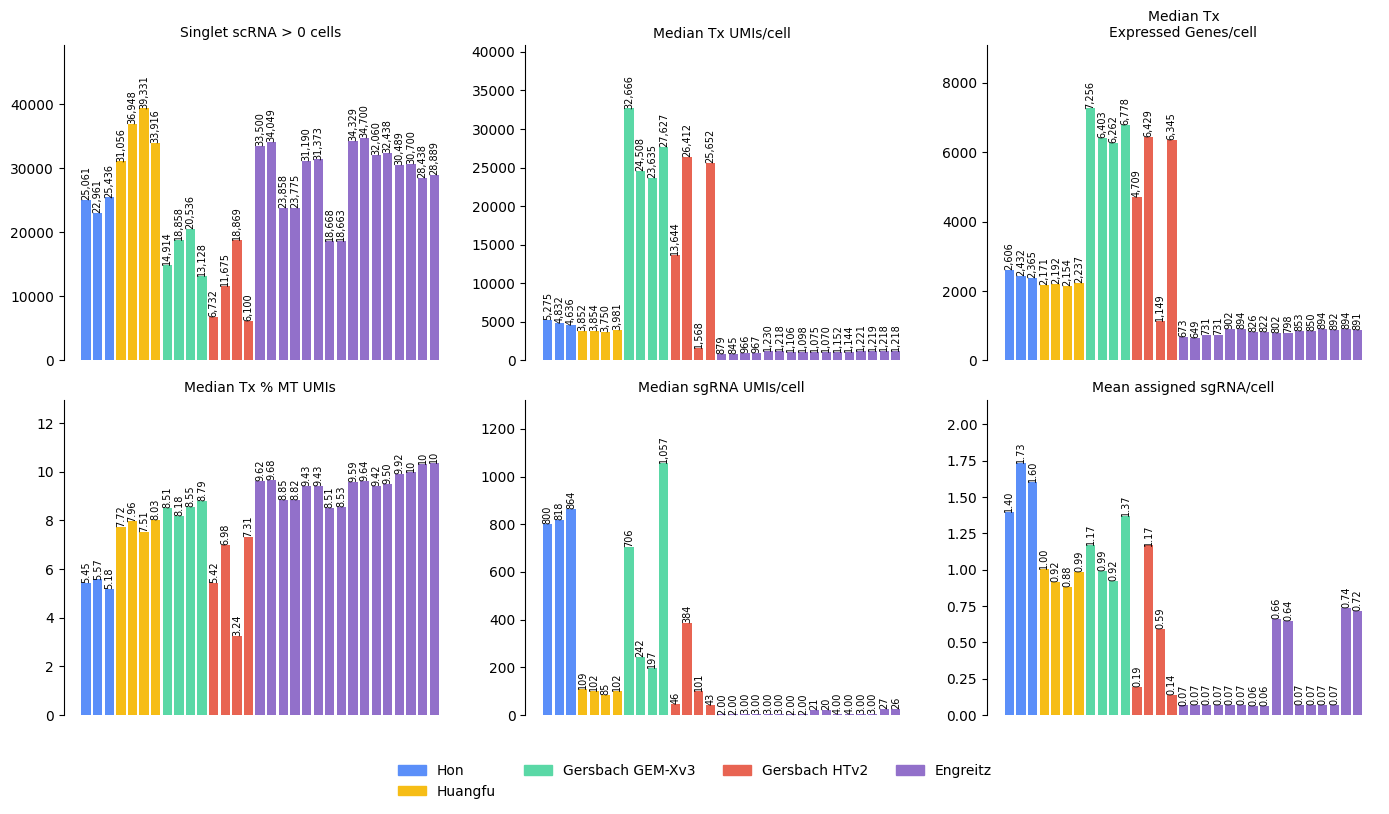

In [93]:
# Metrics to plot in 2x3 grid (matching example image); skip any not present in data
lane_metrics_to_plot = [
    ('n_cells', 'Singlet scRNA > 0 cells'),
    ('umi_median', 'Median Tx UMIs/cell'),
    ('genes_median', 'Median Tx\nExpressed Genes/cell'),
    ('mito_median', 'Median Tx % MT UMIs'),
    ('guide_umi_median', 'Median sgRNA UMIs/cell'),
    ('guides_per_cell_mean', 'Mean assigned sgRNA/cell'),
]
lane_metrics_to_plot = [(col, title) for col, title in lane_metrics_to_plot if col in lane_metrics.columns]

n_plots = len(lane_metrics_to_plot)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for ax, (col, title) in zip(axes, lane_metrics_to_plot):
    colors = [dataset_colors.get(ds, 'gray') for ds in lane_metrics['dataset']]
    x = np.arange(len(lane_metrics))
    bars = ax.bar(x, lane_metrics[col], color=colors, edgecolor='none', width=0.8)
    for i, (bar, val) in enumerate(zip(bars, lane_metrics[col])):
        if pd.notna(val):
            if val >= 1000:
                label = f'{val:,.0f}'
            elif val >= 10:
                label = f'{val:.0f}'
            else:
                label = f'{val:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                   ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ymax = lane_metrics[col].max()
    if pd.notna(ymax):
        ax.set_ylim(0, ymax * 1.25)

# Hide any unused axes
for ax in axes[n_plots:]:
    ax.set_visible(False)

legend_handles = [plt.Rectangle((0,0),1,1, color=dataset_colors[ds]) for ds in dataset_order]
legend_labels = [ds.replace('_WTC11-benchmark_TF-Perturb-seq', '').replace('_', ' ') for ds in dataset_order]
fig.legend(legend_handles, legend_labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig(OUTPUT_DIR / "metrics_by_lane_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [94]:
# Save lane metrics
lane_metrics.to_csv(OUTPUT_DIR / "metrics_by_lane.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'metrics_by_lane.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/metrics_by_lane.tsv


---
# DONE!